In [ ]:
%load_ext autoreload
%autoreload 2

#### 0.获取只基于结构权重估计的核心集,采用全集上的oracle进行估计的全部查询估计平均误差:

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)

from pythonProject.src.Structure_first.compute_truth import GroundTruthManager
from pythonProject.src.Structure_first.proxy_sample import ProxyStratifiedSampler


def _worker_process_single_file(
    agg_file: str,
    aggregated_dir: str,
    all_T_true_results: dict,
    config: dict
):
    """
    [子进程工作函数] 处理单个文件，运行 FastestO 算法并返回指标。
    """
    # 1. 解析查询名
    if agg_file.startswith("aggregated_list_"):
        base = agg_file.replace("aggregated_list_", "")
    elif agg_file.startswith("aggregated_wide_"):
        base = agg_file.replace("aggregated_wide_", "")
    else:
        base = agg_file
    query_basename = base.replace(".csv", "") + ".graph"

    # 2. 获取 T_true
    T_true = all_T_true_results.get(query_basename)
    if T_true is None:
        return None

    filepath = os.path.join(aggregated_dir, agg_file)

    # 3. 初始化 Sampler 并运行
    try:
        sampler = ProxyStratifiedSampler(
            csv_path=filepath,
            is_multi_predicate=True,
            post_proxy=config["post_proxy"],
            comment_proxy=config["comment_proxy"],
            post_oracle=config["post_oracle"],
            comment_oracle=config["comment_oracle"],
            T_true=T_true
        )
        
        if sampler.posts.empty:
            return None

        # 运行 FastestO (Graph Only)
        res = sampler.run_baseline_graph_only()
        
        return {
            "Qerror": res["Qerror"],
            "n_post": res.get("n_post", 0),
            "n_comment": res.get("n_comment", 0),
            "Total_Cost": res.get("n_post", 0) + res.get("n_comment", 0)
        }

    except Exception as e:
        # print(f"[Worker Error] {agg_file}: {e}")
        return None


def evaluate_fastest_o_multi_predicate_dataset_fast(
    dataset_name: str,
    post_proxy_col: str = "ML1_proxy4b_probability",
    comment_proxy_col: str = "ML2_proxy1_probability",
    post_oracle_col: str = "ML1_oracle2_probability",
    comment_oracle_col: str = "ML2_oracle2_probability",
    max_workers: int = None
):
    """
    [多进程加速版] 对指定数据集下的所有查询运行 [FastestO]。
    """
    print(f"\n{'='*10} Evaluation: FastestO (Graph Only / Full Scan) [Fast MP] {'='*10}")
    print(f"Dataset: {dataset_name}")
    print(f"Predicate: Multi-Predicate ({post_oracle_col} & {comment_oracle_col})")

    # 1. 准备 Ground Truth
    gt_manager = GroundTruthManager(dataset_name=dataset_name,
                                    post_oracle_col=post_oracle_col,
                                    comment_oracle_col=comment_oracle_col)
    all_T_true_results = gt_manager.get_all()
    
    if not all_T_true_results:
        print("[Error] 无法获取 T_true，请检查配置。")
        return

    # 2. 准备文件路径
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    aggregated_dir = os.path.join(base_path, "results", "aggregated_results")
    
    if not os.path.exists(aggregated_dir):
        print(f"[Error] 聚合目录不存在: {aggregated_dir}")
        return

    agg_files = sorted([f for f in os.listdir(aggregated_dir) if f.endswith(".csv")])
    
    # 封装配置字典传给子进程
    config = {
        "post_proxy": post_proxy_col,
        "comment_proxy": comment_proxy_col,
        "post_oracle": post_oracle_col,
        "comment_oracle": comment_oracle_col
    }

    # 3. 多进程执行
    metrics = {
        "Qerror": [],
        "Oracle_Cost_Post": [],
        "Oracle_Cost_Comment": [],
        "Total_Cost": []
    }
    
    if max_workers is None:
        max_workers = max(1, os.cpu_count() - 2)
    
    print(f"Starting Process Pool with {max_workers} workers...")
    print(f"Total files to process: {len(agg_files)}")

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        # 提交任务
        futures = []
        for agg_file in agg_files:
            futures.append(
                executor.submit(
                    _worker_process_single_file,
                    agg_file, 
                    aggregated_dir, 
                    all_T_true_results, 
                    config
                )
            )
        
        # 收集结果
        for future in tqdm(as_completed(futures), total=len(futures), desc="Processing Queries"):
            result = future.result()
            if result:
                metrics["Qerror"].append(result["Qerror"])
                metrics["Oracle_Cost_Post"].append(result["n_post"])
                metrics["Oracle_Cost_Comment"].append(result["n_comment"])
                metrics["Total_Cost"].append(result["Total_Cost"])

    # 4. 计算并打印平均值
    if not metrics["Qerror"]:
        print("[Warn] 没有有效查询被处理。")
        return

    avg_qerror = np.mean(metrics["Qerror"])
    avg_post = np.mean(metrics["Oracle_Cost_Post"])
    avg_comment = np.mean(metrics["Oracle_Cost_Comment"])
    avg_total = np.mean(metrics["Total_Cost"])

    print("\n" + "="*50)
    print(f"📊 WO Dataset Summary (N={len(metrics['Qerror'])})")
    print("-" * 50)
    print(f"{'Metric':<25} | {'Average Value':<15}")
    print("-" * 50)
    print(f"{'Mean Qerror (ARE)':<25} | {avg_qerror:.6f}")
    print(f"{'Avg Post Checks':<25} | {avg_post:.1f}")
    print(f"{'Avg Comment Checks':<25} | {avg_comment:.1f}")
    print(f"{'Avg Total Oracle Cost':<25} | {avg_total:.1f}")
    print("=" * 50 + "\n")

    # ==========================================
    # 6. 保存结果到 CSV (新增部分)
    # ==========================================
    output_dir = os.path.join(base_path, "results", "efficiency")
    os.makedirs(output_dir, exist_ok=True)
    output_csv = os.path.join(output_dir, "WO_summary.csv")

    # 创建单行 DataFrame
    summary_data = {
        "dataset_name": [dataset_name],
        "method": ["WO"],
        "num_queries": [len(metrics["Qerror"])],
        "mean_qerror": [avg_qerror],
        "avg_post_checks": [avg_post],
        "avg_comment_checks": [avg_comment],
        "avg_total_cost": [avg_total]
    }
    df_summary = pd.DataFrame(summary_data)

    # 检查文件是否存在，决定是覆盖(header=True)还是追加(header=False)
    # 这里我们使用追加模式 (mode='a')
    file_exists = os.path.exists(output_csv)
    
    try:
        df_summary.to_csv(output_csv, mode='a', header=not file_exists, index=False)
        print(f"✅ 统计结果已保存至: {output_csv}")
    except Exception as e:
        print(f"❌ 保存 CSV 失败: {e}")

# === 调用示例 ===
if __name__ == "__main__":
    evaluate_fastest_o_multi_predicate_dataset_fast("dataset_test")

#### 1. 测试FIOS的误差预算曲线

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.proxy_sample import run_fois_budget_curve_multi_predicate

budget_fracs = [0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5]

df_curve = run_fois_budget_curve_multi_predicate(
    dataset_name="dataset_three",
    budget_fracs=budget_fracs,
    run_times=5,
    post_proxy_col="ML1_proxy4b_probability",
    comment_proxy_col="ML2_proxy1_probability",
    post_oracle_col="ML1_oracle2_probability",
    comment_oracle_col="ML2_oracle2_probability"
)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 平均误差 vs 预算比例
df_plot = df_curve.groupby("budget_frac")["Qerror"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_plot, x="budget_frac", y="Qerror", marker="o")
plt.xlabel("Oracle Budget Fraction")
plt.ylabel("Mean Absolute Relative Error")
plt.title("FOIS_nrs Error vs Oracle Budget (Multi-Predicate)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# 平均误差 vs 实际 oracle_cost
df_plot2 = df_curve.groupby("oracle_cost")["Qerror"].mean().reset_index()

plt.figure(figsize=(7,5))
sns.lineplot(data=df_plot2, x="oracle_cost", y="Qerror", marker="o")
plt.xlabel("Oracle Cost (Unique Post+Comment)")
plt.ylabel("Mean Absolute Relative Error")
plt.title("FOIS_nrs Error vs Oracle Cost")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### 2. FOIS_nrs \ FOIS_rs \ 三种方法的曲线

##### 2.1   FOIS_nrs \ FOIS_rs曲线

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)

budget_fracs = [0.01,0.05, 0.1, 0.15, 0.2,0.25,0.3, 0.4, 0.5,0.6,0.7,0.8,0.9]
from pythonProject.src.Structure_first.proxy_sample import run_budget_curve_multi_predicate
df_curve = run_budget_curve_multi_predicate(
    dataset_name="dataset_test3",
    budget_fracs=budget_fracs,
    run_times=5,
    post_proxy_col="ML1_proxy4b_probability",
    comment_proxy_col="ML2_proxy1_probability",
    post_oracle_col="ML1_oracle2_probability",
    comment_oracle_col="ML2_oracle2_probability"
)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==========================================
# 1. 配置文件路径
# ==========================================
# 请根据你的实际情况修改 dataset_name
dataset_name = 'dataset_one' 
file_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/budget_curve/FOIS_rs_POSS_budget_curve.csv"

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(file_path):
    print(f"[Error] 文件不存在: {file_path}")
else:
    print(f"正在读取文件: {file_path}")
    df_curve = pd.read_csv(file_path)

    # 打印前几行检查数据是否正确
    print(df_curve.head())

    # ==========================================
    # 3. 数据聚合 (计算平均误差)
    # ==========================================
    # 按照 方法 和 预算比例 分组，计算 Qerror 的平均值
    df_plot = df_curve.groupby(["method", "budget_frac"])["Qerror"].mean().reset_index()

    # ==========================================
    # 4. 绘图
    # ==========================================
    # 设置学术风格
    sns.set_style("whitegrid")
    plt.figure(figsize=(8, 6))

    # 绘制折线图
    # style="method" 会自动给不同方法分配不同的线型/标记，适合黑白打印
    sns.lineplot(
        data=df_plot, 
        x="budget_frac", 
        y="Qerror", 
        hue="method", 
        style="method", 
        markers=True, 
        dashes=False, # 如果不喜欢虚线，设为 False
        markersize=8,
        linewidth=2
    )

    # 设置标签和标题
    plt.xlabel("Oracle Budget Fraction (Sampling Ratio)", fontsize=12, fontweight='bold')
    plt.ylabel("Mean Absolute Relative Error", fontsize=12, fontweight='bold')
    plt.title(f"Error Convergence: {dataset_name}", fontsize=14)

    # 可选：如果误差下降很快，建议使用对数坐标
    # plt.yscale('log') 
    # plt.xscale('log') # 预算跨度大时也建议开启

    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    plt.legend(title="Method", fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    plt.show()

##### 2.2 POSS 曲线

In [ ]:
import os
import re
import sys
import math
import time
import tempfile
import traceback
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.proxy_sample import run_adaptive_sampling_experiment


run_adaptive_sampling_experiment(dataset_name="dataset_test", run_times=5)

#### 3.基线方法 FastestO

In [ ]:
import os
import re
import sys
from typing import List, Dict, Tuple
import pandas as pd
import numpy as np
import json
project_root = "/home/wangshuo/projects/Neo4j_Exp"
if project_root not in sys.path:
    sys.path.append(project_root)
from pythonProject.src.Structure_first.fastest_pipeline import FastestGraphConverter, FastestEstimateMerger
from pythonProject.src.Structure_first.graph_sample import FastestRunner
from pythonProject.src.Structure_first.precision_submatching import ExactSubgraphMatcher
from pythonProject.src.Structure_first.proxy_sample import ProxyStratifiedSampler, compute_T_true

# 一级测试数据集
datasets_name = "parler_data"
# 一级数据集下根据查询和图结构的差异划分的子测试数据集
dataset_name = "dataset_three"
current_budget = 20000

# 初始化 Runner

infer_label = 1
post_col = "ML1_oracle2_probability"
comment_col = "ML2_oracle2_probability"
proxy_folder = "ML1_proxy4b_probability_ML2_proxy1_probability"
runner = FastestRunner(build_dir="/home/wangshuo/projects/FaSTest-main/build")

code, output = runner.run(
    dataset=dataset_name,
    root_label=infer_label,
    sample_budget=current_budget,
    estimate_with_predicate=True,
    post_oracle_col=post_col,
    comment_oracle_col=comment_col,
    multi_proxy_prob=proxy_folder,
    fastesto_budget_curve=True,
    fastesto_runs=5,
    fastesto_budget_curve_out=f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency/FastestO_budget_curve.csv"
)

#### 4. 读取FastestO_budget_curve.csv  和 FOIS_rs_POSS_budget_curve.csv 文件的内容, 绘制误差-时间曲线:

##### 4.1 折线

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'  # 请修改为实际数据集名称
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径 (保持不变)
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve1.csv")
path_fast = os.path.join("/home/wangshuo/resource/datasets/parler_data/dataset_three/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

# --- 强制统一方法名为 FastestO ---
df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式 (清洗数据)
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth (T_true) 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
print(f"提取到 {len(truth_map)} 个查询的真实值基准。")

df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
if X_AXIS_COL not in df_fast.columns:
    print(f"[Warn] FastestO 数据缺少 {X_AXIS_COL} 列，可能导致绘图失败。")

df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)

# --- 计算绝对相对误差 (ARE) ---
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

print("聚合后的数据预览:")
print(df_plot.head())

# ==========================================
# 7. 绘图 (美化版 - 定制坐标轴)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 绘制折线图
ax = sns.lineplot(
    data=df_plot,
    x=X_AXIS_COL,
    y="ARE",
    hue="method",
    style="method",
    hue_order=hue_order,
    style_order=hue_order,
    markers=True,
    dashes=False,
    markersize=10,
    linewidth=2.5,
    alpha=0.9,
    palette="tab10"
)

# --- [核心修改] 轴格式化 ---

# 1. X轴设置
plt.xscale('log')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 手动设置 X 轴刻度，强制显示 0.01, 0.05, 0.1 等
# 根据你的数据范围，这里列出常用的采样率点
target_ticks = [0.05, 0.1,0.15, 0.2,0.3,0.4, 0.5, 1.0]
# 过滤掉超出数据范围的刻度
min_x, max_x = df_plot[X_AXIS_COL].min(), df_plot[X_AXIS_COL].max()
final_ticks = [t for t in target_ticks if min_x <= t <= max_x]

# 强制应用刻度
ax.set_xticks(final_ticks)
# 强制使用普通小数格式 (ScalarFormatter)，并关闭科学计数法
x_formatter = ScalarFormatter()
x_formatter.set_scientific(False)
ax.get_xaxis().set_major_formatter(x_formatter)


# 2. Y轴设置
plt.yscale('log') # 保持 Log 坐标以便观察收敛
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

# 自定义 Y 轴格式化函数：强制显示小数
def decimal_formatter(x, pos):
    # 根据数值大小动态调整小数位，避免显示 0.00
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
# 移除次级刻度的科学计数法干扰
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 


# --- [修改] 在图上显示具体数值 (也改为小数) ---
for method in hue_order:
    subset = df_plot[df_plot['method'] == method]
    
    for i, row in subset.iterrows():
        x_val = row[X_AXIS_COL]
        y_val = row['ARE']
        
        # 格式化文本: 改为保留3位小数 (如 0.125)
        label_text = f"{y_val:.3f}"
        
        # 智能偏移
        xytext_offset = (0, 8) 
        if method == 'FastestO': 
            xytext_offset = (0, -14)
        elif method == 'POSS':
            xytext_offset = (0, 8)
        
        ax.annotate(
            label_text,
            xy=(x_val, y_val),
            xytext=xytext_offset, 
            textcoords='offset points',
            ha='center', va='center',
            fontsize=9, fontweight='bold', color='black',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
        )

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Mean ARE) ======")
print(df_plot.pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.2曲线

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve1.csv")
path_fast = os.path.join(f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.05, 0.1, 0.15, 0.3, 0.4, 0.5, 1.0]

# [新增配置] 控制曲线拟合的数据源
# True:  使用 CSV 中所有数据拟合曲线（曲线更真实，但受中间点影响）
# False: 只使用 TARGET_TICKS 中的点拟合曲线（忽略 CSV 中的 0.01, 0.02 等点）
# USE_ALL_DATA_FOR_CURVE = False 
USE_ALL_DATA_FOR_CURVE = True 

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图 (平滑曲线 + 筛选散点)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序和颜色/形状映射
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 获取 Seaborn tab10 的颜色
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(hue_order, ['o', 's', '^', 'D'])) 

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    # 获取原始的所有数据
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 (根据配置筛选) ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        # 使用所有数据拟合
        x_fit = x_raw
        y_fit = y_raw
    else:
        # 只使用 TARGET_TICKS 中的数据拟合
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 ---
    if len(x_fit) > 2: 
        try:
            # Log 空间插值
            x_new = np.logspace(np.log10(x_fit.min()), np.log10(x_fit.max()), 300)
            spl = make_interp_spline(np.log10(x_fit), y_fit, k=3)
            y_smooth = spl(np.log10(x_new))
            y_smooth = np.maximum(y_smooth, 0) # 误差非负
            
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
        except:
            # 如果拟合失败（如点过于分散），回退到直接连线
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
    else:
        # 点太少，无法做样条插值，直接连线
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)

    # --- C. 绘制筛选后的散点 (始终只画 TARGET_TICKS) ---
    # 注意：这里的数据始终来自 x_raw 经过 mask 过滤，确保散点只出现在指定位置
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map[method], s=80, zorder=5)

        # --- D. 绘制筛选后的数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            # 智能偏移
            xytext_offset = (0, 10) 
            if method == 'FastestO': 
                xytext_offset = (0, -15)
            elif method == 'POSS':
                xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------

ax = plt.gca()

# X轴设置
plt.xscale('log')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 过滤掉超出数据范围的 target ticks
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

# 强制只显示自定义的刻度
ax.set_xticks(final_ticks)
x_formatter = ScalarFormatter()
x_formatter.set_scientific(False)
ax.get_xaxis().set_major_formatter(x_formatter)

# Y轴设置
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
# 只展示筛选后的点，方便核对
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.3 调整展示数据

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency", "FastestO_budget_curve.csv")

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.01, 0.05, 0.1, 0.15, 0.2,0.25,0.3, 0.4, 0.5,0.6,0.7,0.8,0.9, 1.0]

# [新增配置] 控制曲线拟合的数据源
# False: 只使用 TARGET_TICKS 中的点拟合曲线
USE_ALL_DATA_FOR_CURVE = False 

# ==========================================
# 2. 读取数据
# ==========================================
if not os.path.exists(path_fois) or not os.path.exists(path_fast):
    print(f"[Error] 文件不存在，请检查路径:\n {path_fois} \n {path_fast}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)
df_fast = pd.read_csv(path_fast)

df_fast['method'] = 'FastestO'

# ==========================================
# 3. 统一文件名格式
# ==========================================
df_fois['query_basename'] = df_fois['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
df_fast['query_basename'] = df_fast['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# ==========================================
# 4. 提取 Ground Truth 并对齐
# ==========================================
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()
df_fast['T_true'] = df_fast['query_basename'].map(truth_map)
df_fast = df_fast.dropna(subset=['T_true'])

# ==========================================
# 5. 合并数据 & 计算误差
# ==========================================
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']
df_all = pd.concat([df_fois[cols], df_fast[cols]], ignore_index=True)
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图 (平滑曲线 + 筛选散点)
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(hue_order, ['o', 's', '^', 'D'])) 

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit = x_raw
        y_fit = y_raw
    else:
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 (修改为线性空间插值) ---
    if len(x_fit) > 2: 
        try:
            # [修改点] 使用 linspace 生成线性等分的点，而不是 logspace
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            
            # [修改点] 去掉 np.log10，直接拟合 X -> Y 的关系
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0) 
            
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.9, label=method)

    # --- C. 绘制筛选后的散点 ---
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map[method], s=80, zorder=5)

        # --- D. 绘制数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            xytext_offset = (0, 10) 
            if method == 'FastestO': 
                xytext_offset = (0, -15)
            elif method == 'POSS':
                xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=9, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------

ax = plt.gca()

# [修改点] X轴设置：改为 linear (线性)，这会让差距按正常比例显示
plt.xscale('linear')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')

# 设置显示范围，留一点边距让 0.05 和 1.0 不会贴边
plt.xlim(0, 1.0) 

# 设置刻度
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

# Y轴设置 (Y轴通常还是保持Log比较好，如果你也想线性，可以把这里也改成 linear)
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.5f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

# 标题与图例
plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

# 网格线
plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.4 修改下面代码,添加WJU_WJP_budget_curve.csv 结果作对比

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
# dataset_name = 'dataset_test3'
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_wju  = os.path.join(base_dir, "WJU_WJP_budget_curve.csv") 

# 绘图配置
X_AXIS_COL = "budget_frac" 
X_LABEL = "Sampling Budget Fraction"

# [核心配置] 只在这些预算点显示散点和数值
TARGET_TICKS = [0.01,0.05, 0.1,0.2, 0.15, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# [新增配置] 控制曲线拟合的数据源
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
# 检查必要文件 (FOIS是基准，必须存在)
if not os.path.exists(path_fois):
    print(f"[Error] 基准文件不存在: {path_fois}")
    exit()

print("正在读取数据...")
df_fois = pd.read_csv(path_fois)

# 读取对比方法 (允许部分文件缺失，但这会影响对比)
dfs_to_merge = [df_fois]

if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast['method'] = 'FastestO'
    dfs_to_merge.append(df_fast)
else:
    print(f"[Warn] FastestO 文件未找到: {path_fast}")

if os.path.exists(path_wju):
    df_wju = pd.read_csv(path_wju)
    # WJU文件里通常已经包含了 'method' 列 (WJU/WJP)
    dfs_to_merge.append(df_wju)
else:
    print(f"[Warn] WJU/WJP 文件未找到: {path_wju}")

# ==========================================
# 3. 数据清洗与 Ground Truth 对齐
# ==========================================
# 3.1 统一文件名格式 (去除 .graph)
for df in dfs_to_merge:
    if 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)

# 3.2 提取 Ground Truth (以 FOIS 为准)
truth_map = df_fois[['query_basename', 'T_true']].drop_duplicates(subset=['query_basename']).set_index('query_basename')['T_true'].to_dict()

# 3.3 映射 Truth 并合并
df_final_list = []
cols = ['query_basename', 'method', X_AXIS_COL, 'T_hat', 'T_true']

for df in dfs_to_merge:
    # 确保列存在
    temp_df = df.copy()
    
    # 如果不是 FOIS (即没有原始 T_true 或者 T_true 可能不一致)，强制覆盖
    # 这里我们对所有非 FOIS 数据都做一次 map 以防万一
    if df is not df_fois:
        temp_df['T_true'] = temp_df['query_basename'].map(truth_map)
        # 过滤掉无法匹配 T_true 的脏数据
        temp_df = temp_df.dropna(subset=['T_true'])
    
    # 只取需要的列
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 5. 计算误差
# ==========================================
df_all['ARE'] = ((df_all['T_hat'] - df_all['T_true']) / df_all['T_true']).abs()

# ==========================================
# 6. 数据聚合
# ==========================================
df_plot = df_all.groupby(['method', X_AXIS_COL])['ARE'].mean().reset_index()

# ==========================================
# 7. 绘图
# ==========================================
sns.set_style("whitegrid", {'grid.linestyle': '--'})
plt.figure(figsize=(10, 7))

# 定义绘图顺序 (添加 WJU, WJP)
desired_order = ['FOIS_nrs', 'FOIS_rs', 'POSS', 'FastestO', 'WJU', 'WJP']
hue_order = [m for m in desired_order if m in df_plot['method'].unique()]

# 扩展颜色和标记
# Tab10 只有10种颜色，足够用
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
# 定义标记：WJU用倒三角(v)，WJP用叉号(X)
marker_map = dict(zip(desired_order, ['o', 's', '^', 'D', 'v', 'X']))

for method in hue_order:
    subset = df_plot[df_plot['method'] == method].sort_values(by=X_AXIS_COL)
    
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset['ARE'].values

    # --- A. 准备拟合用的数据 ---
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit = x_raw
        y_fit = y_raw
    else:
        x_fit = x_raw[mask_target]
        y_fit = y_raw[mask_target]

    # --- B. 绘制平滑曲线 ---
    if len(x_fit) > 2: 
        try:
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0) 
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # --- C. 绘制筛选后的散点 ---
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]

    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map.get(method, 'o'), s=80, zorder=5)

        # --- D. 绘制数值标注 ---
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"
            
            # 智能偏移策略 (防止重叠)
            xytext_offset = (0, 10) 
            if method == 'FastestO': xytext_offset = (0, -15)
            elif method == 'WJU': xytext_offset = (0, 15) # WJU通常误差最大，往上飘
            elif method == 'WJP': xytext_offset = (0, -15)
            elif method == 'POSS': xytext_offset = (0, 10)
            
            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset, 
                textcoords='offset points',
                ha='center', va='center',
                fontsize=8, fontweight='bold', color='black',
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

# -------------------------------------------------------
# 轴格式化
# -------------------------------------------------------
ax = plt.gca()

# X轴设置：线性
plt.xscale('linear')
plt.xlabel(X_LABEL, fontsize=14, fontweight='bold')
plt.xlim(0, 1.05) 

# 设置刻度
min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]

ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

# Y轴设置：Log
plt.yscale('log') 
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight='bold')

def decimal_formatter(x, pos):
    if x < 0.01: return f'{x:.3f}'
    if x < 0.1:  return f'{x:.2f}'
    return f'{x:.2f}'

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: "")) 

plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc='best', frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# 打印统计信息
# ==========================================
print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns='method', values='ARE'))

##### 4.5添加proxyE
我想将WJU_WJP_budget_curve 换成 proxy_importance_budget_curve.csv ,WJU和WJP换成两个新方法proxy_importance,proxy_importance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_three'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_proxy = os.path.join(base_dir, "two_stage_adaptive_results.csv")

# 绘图配置
X_AXIS_COL = "budget_frac"
X_LABEL = "Sampling Budget Fraction"

TARGET_TICKS = [0.01, 0.05, 0.1, 0.2, 0.15, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

# 2.1 读取 FOIS (这是现在的 Ground Truth 来源，必须存在)
if not os.path.exists(path_fois):
    print(f"[Error] FOIS 文件不存在 (基准文件缺失): {path_fois}")
    exit()
df_fois = pd.read_csv(path_fois)

# 2.2 读取 FastestO
dfs_to_merge = [df_fois]

if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs_to_merge.append(df_fast)
else:
    print(f"[Warn] FastestO 文件未找到: {path_fast}")

# 2.3 读取 Proxy Importance
if os.path.exists(path_proxy):
    df_proxy = pd.read_csv(path_proxy)
    # csv中已经包含了 method 列 (proxy_importance, proxyE_importance)
    dfs_to_merge.append(df_proxy)
else:
    print(f"[Warn] proxy_importance 文件未找到: {path_proxy}")

# ==========================================
# 3. 数据清洗与 GT 对齐 (以 FOIS 为 GT)
# ==========================================

# 3.1 第一步：统一文件名格式 (去除 .graph 后缀)
# 这一步非常重要，否则名字对不上，无法提取 T_true
for df in dfs_to_merge:
    if "query_basename" in df.columns:
        df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)

# 3.2 第二步：从 FOIS 中提取 Ground Truth 字典
# [核心修改] 这里改成 df_fois
truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()

print(f"-> 以 FOIS 为基准，加载了 {len(truth_map)} 条 Ground Truth。")

# 3.3 第三步：将 GT 映射到其他数据上
df_final_list = []
cols = ["query_basename", "method", X_AXIS_COL, "T_hat", "T_true"]

for df in dfs_to_merge:
    temp_df = df.copy()
    
    # [核心修改] 如果不是 FOIS，就强制用 FOIS 的 Truth 覆盖
    if df is not df_fois:
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        
        # 丢弃那些在 FOIS 里没找到对应 GT 的行
        # (例如 FastestO 跑了一个 FOIS 没跑的 query，由于没有真值，无法计算误差，必须丢弃)
        before_len = len(temp_df)
        temp_df = temp_df.dropna(subset=["T_true"])
        after_len = len(temp_df)
        if before_len > after_len:
            print(f"   [Info] {temp_df['method'].iloc[0] if not temp_df.empty else 'Unknown'} 丢弃了 {before_len - after_len} 行匹配不到 GT 的数据")

    # 提取需要的列
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 4. 计算误差
# ==========================================
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 5. 数据聚合
# ==========================================
df_plot = df_all.groupby(["method", X_AXIS_COL])["ARE"].mean().reset_index()

# ==========================================
# 6. 绘图
# ==========================================
sns.set_style("whitegrid", {"grid.linestyle": "--"})
plt.figure(figsize=(10, 7))

# 定义顺序
desired_order = ["FOIS_nrs", "FOIS_rs", "POSS", "FastestO", "proxy_importance", "proxyE_importance"]
hue_order = [m for m in desired_order if m in df_plot["method"].unique()]

# 颜色与标记
palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))
marker_map = dict(zip(desired_order, ["o", "s", "^", "D", "v", "X"]))

for method in hue_order:
    subset = df_plot[df_plot["method"] == method].sort_values(by=X_AXIS_COL)

    x_raw = subset[X_AXIS_COL].values
    y_raw = subset["ARE"].values

    # 过滤显示点
    mask_target = []
    for x_val in x_raw:
        is_target = any(np.isclose(x_val, t, atol=1e-4) for t in TARGET_TICKS)
        mask_target.append(is_target)
    mask_target = np.array(mask_target)

    if USE_ALL_DATA_FOR_CURVE:
        x_fit, y_fit = x_raw, y_raw
    else:
        x_fit, y_fit = x_raw[mask_target], y_raw[mask_target]

    # 绘制曲线 (带容错)
    if len(x_fit) > 2:
        try:
            x_new = np.linspace(x_fit.min(), x_fit.max(), 300)
            spl = make_interp_spline(x_fit, y_fit, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0)
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_fit, y_fit, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # 绘制散点
    x_markers = x_raw[mask_target]
    y_markers = y_raw[mask_target]
    if len(x_markers) > 0:
        plt.scatter(x_markers, y_markers, color=color_map[method], marker=marker_map.get(method, "o"), s=80, zorder=5)
        
        # 绘制标签
        for i in range(len(x_markers)):
            x_val = x_markers[i]
            y_val = y_markers[i]
            label_text = f"{y_val:.3f}"

            # 智能偏移
            xytext_offset = (0, 10)
            if method == "FastestO": xytext_offset = (0, -15)
            elif method == "proxy_importance": xytext_offset = (0, 15)
            elif method == "proxyE_importance": xytext_offset = (0, -15)
            elif method == "POSS": xytext_offset = (0, 10)

            plt.annotate(
                label_text,
                xy=(x_val, y_val),
                xytext=xytext_offset,
                textcoords="offset points",
                ha="center", va="center",
                fontsize=8, fontweight="bold", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none")
            )

ax = plt.gca()
plt.xscale("linear")
plt.xlabel(X_LABEL, fontsize=14, fontweight="bold")
plt.xlim(0, 1.05)

min_x_plot = df_plot[X_AXIS_COL].min()
max_x_plot = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x_plot * 0.9 <= t <= max_x_plot * 1.1]
ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

plt.yscale("log")
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight="bold")

def decimal_formatter(x, pos):
    if x < 0.01: return f"{x:.3f}"
    if x < 0.1:  return f"{x:.2f}"
    return f"{x:.2f}"

ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda x, _: ""))

plt.title(f"Error Convergence: {dataset_name}", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=11, title_fontsize=12, loc="best", frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

print("\n====== Data Summary (Filtered Points) ======")
mask_all = df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-4) for t in TARGET_TICKS))
print(df_plot[mask_all].pivot(index=X_AXIS_COL, columns="method", values="ARE"))

##### 4.6添加proxyE
将 FOIS_nrs \ FOIS_rs \ FastestO \ 四种分层采样

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison.csv")
# --- 文件路径 ---
# path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")    # 这里面通常包含 FOIS_nrs 和 FOIS_rs
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
path_wo_summary = os.path.join(base_dir, "WO_summary.csv") 

# --- 绘图配置 ---
X_AXIS_COL = "budget_frac"
X_LABEL = "Sampling Budget Fraction"

TARGET_TICKS = [0.01, 0.05, 0.1, 0.15,0.2,0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9,0.95]
USE_ALL_DATA_FOR_CURVE = True

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")

dfs_to_merge = []

# 2.1 读取 FOIS (包含 nrs 和 rs)
if not os.path.exists(path_fois):
    print(f"[Error] FOIS 文件不存在: {path_fois}")
    exit()
df_fois = pd.read_csv(path_fois)
dfs_to_merge.append(df_fois)

# 2.2 读取 FastestO
if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs_to_merge.append(df_fast)

# 2.3 读取 新的策略对比
if os.path.exists(path_alloc_new):
    df_alloc = pd.read_csv(path_alloc_new)
    dfs_to_merge.append(df_alloc)
else:
    print(f"[Warn] 新策略文件未找到: {path_alloc_new}")

# ==========================================
# 2.4 [修改] 动态从 WO_summary.csv 提取 mean_qerror
# ==========================================
# 假设文件名已改为 WO_summary.csv
wo_mean_error = None
if os.path.exists(path_wo_summary):
    try:
        df_sum = pd.read_csv(path_wo_summary)
        
        # 筛选 dataset_name (防止文件中包含多个数据集的记录)
        # 注意：确保 CSV 中的 dataset_name 列的值与脚本开头的 dataset_name 变量一致
        row = df_sum[df_sum["dataset_name"] == dataset_name]
        
        if not row.empty:
            wo_mean_error = row["mean_qerror"].iloc[0]
            print(f"✅ 已从 WO_summary.csv 加载基准误差: {wo_mean_error}")
        else:
            print(f"[Warn] WO_summary.csv 中未找到 dataset_name='{dataset_name}' 的记录。")
            # 备用：如果没找到对应名字，且文件只有一行，尝试直接读第一行（可选）
            if len(df_sum) == 1:
                wo_mean_error = df_sum["mean_qerror"].iloc[0]
                print(f"   ->由于文件仅有一行，已回退使用第一行数据: {wo_mean_error}")

    except Exception as e:
        print(f"[Error] 读取 WO_summary.csv 失败: {e}")
else:
    print(f"[Warn] WO Summary 文件未找到: {path_wo_summary}")
# ==========================================
# 3. 数据清洗与 GT 对齐
# ==========================================
print("正在处理数据...")

# 3.1 统一文件名
for df in dfs_to_merge:
    if "query_basename" in df.columns:
        df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)

# 3.2 提取 GT 字典 (以 FOIS 文件为准)
truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()

# 3.3 合并
df_final_list = []
cols = ["query_basename", "method", X_AXIS_COL, "T_hat", "T_true"]

for df in dfs_to_merge:
    temp_df = df.copy()
    if df is not df_fois:
        temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
        temp_df = temp_df.dropna(subset=["T_true"])
    
    if set(cols).issubset(temp_df.columns):
        df_final_list.append(temp_df[cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# ==========================================
# 4. 计算误差
# ==========================================
df_all = df_all[df_all["T_true"] != 0]
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 5. 聚合
# ==========================================
df_plot = df_all.groupby(["method", X_AXIS_COL])["ARE"].mean().reset_index()

# ==========================================
# 6. 绘图 (核心修改)
# ==========================================
sns.set_style("whitegrid", {"grid.linestyle": "--"})
plt.figure(figsize=(12, 8))

# --- [修改点 1] 添加 FOIS_nrs 到顺序列表 ---
desired_order = [
    "FOIS_nrs",             # <--- 新增
    "FOIS_rs", 
    # "FastestO",
    "WO", 
    # "1_Proxy_Imp_Pilot",
    # "2_ProxyE_Imp_Pilot",
    # "3_ProxyE_Imp_RootWP",
    # "4_ProxyE_Imp_WRootMeanP",
    "5_ProxyE_Imp_Sqrt_WP",
    # "6_ProxyE_Imp_Neyman"
    "7_ProxyE_Imp_Sqrt_WP_NRS"
]
hue_order = [m for m in desired_order if m in df_plot["method"].unique()]

palette = sns.color_palette("tab10", n_colors=len(hue_order))
color_map = dict(zip(hue_order, palette))

# --- [修改点 2] 为 FOIS_nrs 分配 Marker ---
marker_dict = {
    "FOIS_nrs": "o",            # 圆圈 (和 rs 区分)
    "FOIS_rs": "s",             # 方块
    "FastestO": "D",            # 菱形
    "WO": "^",                  # 三角形
    "1_Proxy_Imp_Pilot": "p",      # 五边形 (原先是o，改为p避免冲突)
    "2_ProxyE_Imp_Pilot": "X",     # 叉号
    "3_ProxyE_Imp_RootWP": "*",    # 星号
    "4_ProxyE_Imp_WRootMeanP": "*" # 加号
}

# --- [修改点 3] 为 FOIS_nrs 分配 标签偏移 ---
offset_map = {
    "FOIS_nrs": (0, -15),        # 向下
    "FOIS_rs": (0, 15),          # 向上
    "FastestO": (15, 0),         # 向右
    
    "1_Proxy_Imp_Pilot": (-10, 10),
    "2_ProxyE_Imp_Pilot": (10, 10),
    "3_ProxyE_Imp_RootWP": (-10, -15),
    "4_ProxyE_Imp_WRootMeanP": (10, -15)
}

default_offset = (0, 10)

for method in hue_order:
    subset = df_plot[df_plot["method"] == method].sort_values(by=X_AXIS_COL)
    x_raw = subset[X_AXIS_COL].values
    y_raw = subset["ARE"].values

    # 平滑曲线
    if len(x_raw) > 3 and USE_ALL_DATA_FOR_CURVE:
        try:
            x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
            spl = make_interp_spline(x_raw, y_raw, k=3)
            y_smooth = spl(x_new)
            y_smooth = np.maximum(y_smooth, 0)
            plt.plot(x_new, y_smooth, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
        except:
            plt.plot(x_raw, y_raw, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)
    else:
        plt.plot(x_raw, y_raw, color=color_map[method], linewidth=2.5, alpha=0.8, label=method)

    # 散点
    mask = [any(np.isclose(x, t, atol=1e-3) for t in TARGET_TICKS) for x in x_raw]
    x_pts = x_raw[mask]
    y_pts = y_raw[mask]
    
    if len(x_pts) > 0:
        mk = marker_dict.get(method, "o")
        plt.scatter(x_pts, y_pts, color=color_map[method], marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)

        # 标签
        for i in range(len(x_pts)):
            # 仅在关键点显示数值，避免拥挤
            if x_pts[i] in [0.05, 0.1, 0.3, 0.5, 1.0]: 
                lbl = f"{y_pts[i]:.3f}"
                off = offset_map.get(method, default_offset)
                
                plt.annotate(
                    lbl, 
                    xy=(x_pts[i], y_pts[i]), 
                    xytext=off,
                    textcoords="offset points",
                    ha="center", va="center",
                    fontsize=7, fontweight="bold",
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none")
                )


# ==========================================
# 7.  绘制 WO 平均误差横线
# ==========================================
if wo_mean_error is not None:
    # 绘制横线
    plt.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
    
    # 在图表右边缘添加文本标注
    # transform=ax.get_yaxis_transform() 使得 x=1.02 表示在轴外右侧
    plt.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}", 
             color='black', fontsize=9, fontweight='bold', va='center', ha='left', 
             transform=plt.gca().get_yaxis_transform())
# ==========================================
ax = plt.gca()
plt.xscale("linear")
plt.xlabel(X_LABEL, fontsize=14, fontweight="bold")
plt.xlim(0, 1.05)

min_x = df_plot[X_AXIS_COL].min()
max_x = df_plot[X_AXIS_COL].max()
final_ticks = [t for t in TARGET_TICKS if min_x * 0.9 <= t <= max_x * 1.1]
ax.set_xticks(final_ticks)
ax.get_xaxis().set_major_formatter(ScalarFormatter())

plt.yscale("log")
plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight="bold")
def decimal_formatter(x, pos): return f"{x:.2g}"
ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))

plt.title(f"Performance Comparison: FOIS vs Adaptive Allocations", fontsize=16, pad=15)
plt.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)

plt.grid(True, which="major", linestyle="-", linewidth=0.8, alpha=0.8)
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

# 打印数据
print("\n====== Summary (Pivot) ======")
df_filtered = df_plot[df_plot[X_AXIS_COL].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in TARGET_TICKS))]
print(df_filtered.pivot(index=X_AXIS_COL, columns="method", values="ARE"))

##### 4.7


🚀 开始处理数据集: dataset_three
正在加载数据集: dataset_three ...
✅ 已加载 WO 基准误差: 0.031552677819197

绘制误差收敛曲线...


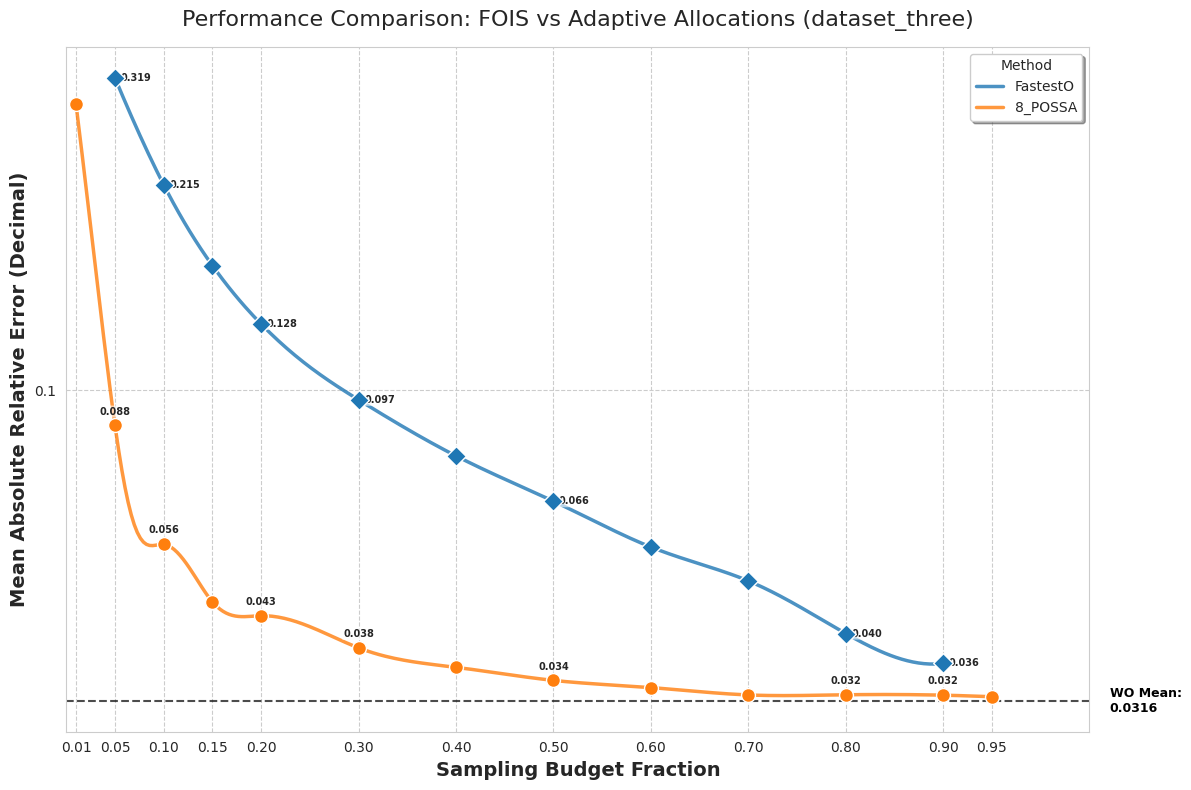


====== Summary of Mean ARE (Pivot) ======
method       5_ProxyE_Imp_Sqrt_WP  7_ProxyE_Imp_Sqrt_WP_NRS   8_POSSA  \
budget_frac                                                             
0.01                     0.300746                  0.282433  0.289688   
0.05                     0.119893                  0.087539  0.087774   
0.10                     0.074975                  0.054648  0.056396   
0.15                     0.046066                  0.047432  0.045539   
0.20                     0.041933                  0.043163  0.043259   
0.30                     0.038369                  0.041430  0.038388   
0.40                     0.036589                  0.036507  0.035706   
0.50                     0.034942                  0.036985  0.034014   
0.60                     0.033098                  0.035637  0.033115   
0.70                     0.032330                  0.035598  0.032221   
0.80                     0.032265                  0.035314  0.032242   
0.90    

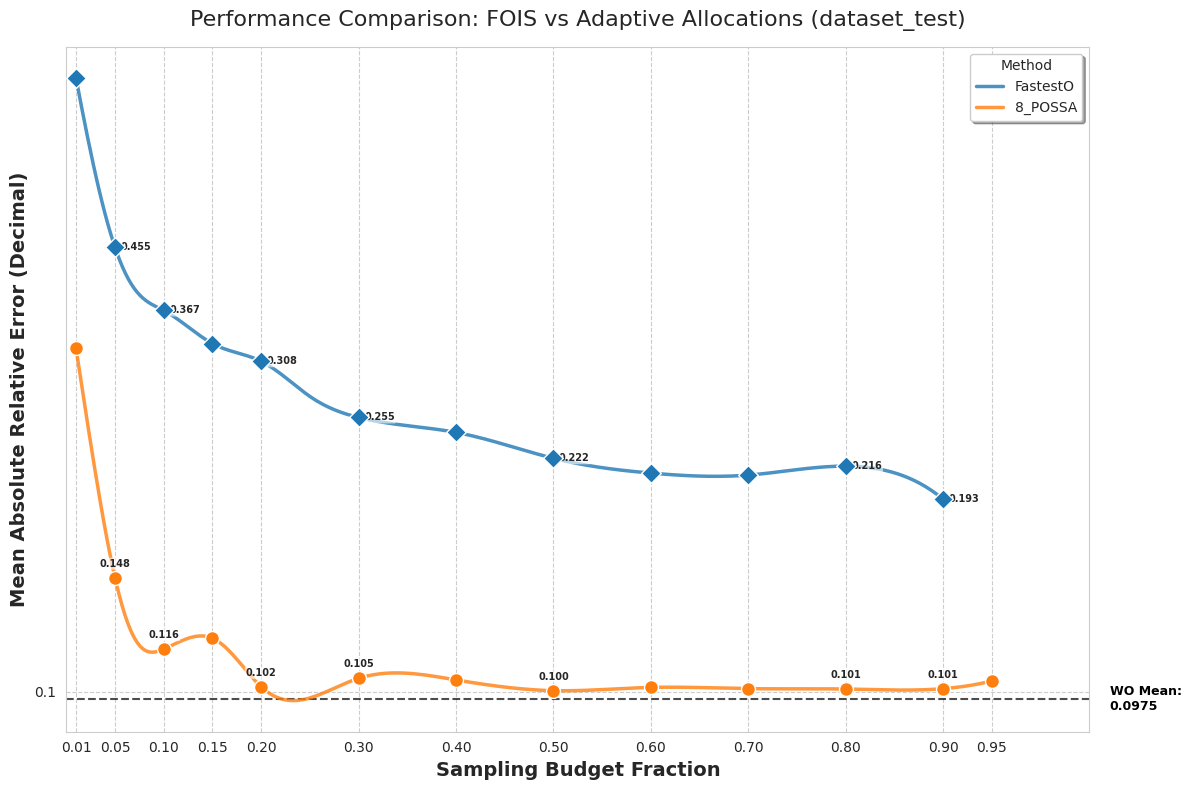


====== Summary of Mean ARE (Pivot) ======
method       5_ProxyE_Imp_Sqrt_WP  7_ProxyE_Imp_Sqrt_WP_NRS   8_POSSA  \
budget_frac                                                             
0.01                     0.312131                  0.312837  0.322449   
0.05                     0.154296                  0.144948  0.147547   
0.10                     0.125483                  0.132216  0.115680   
0.15                     0.107683                  0.109560  0.120039   
0.20                     0.108199                  0.125827  0.101726   
0.30                     0.102677                  0.107004  0.104705   
0.40                     0.102882                  0.107815  0.104137   
0.50                     0.108379                  0.107314  0.100395   
0.60                     0.101208                  0.105105  0.101511   
0.70                     0.100590                  0.105766  0.101088   
0.80                     0.101811                  0.104753  0.100950   
0.90    

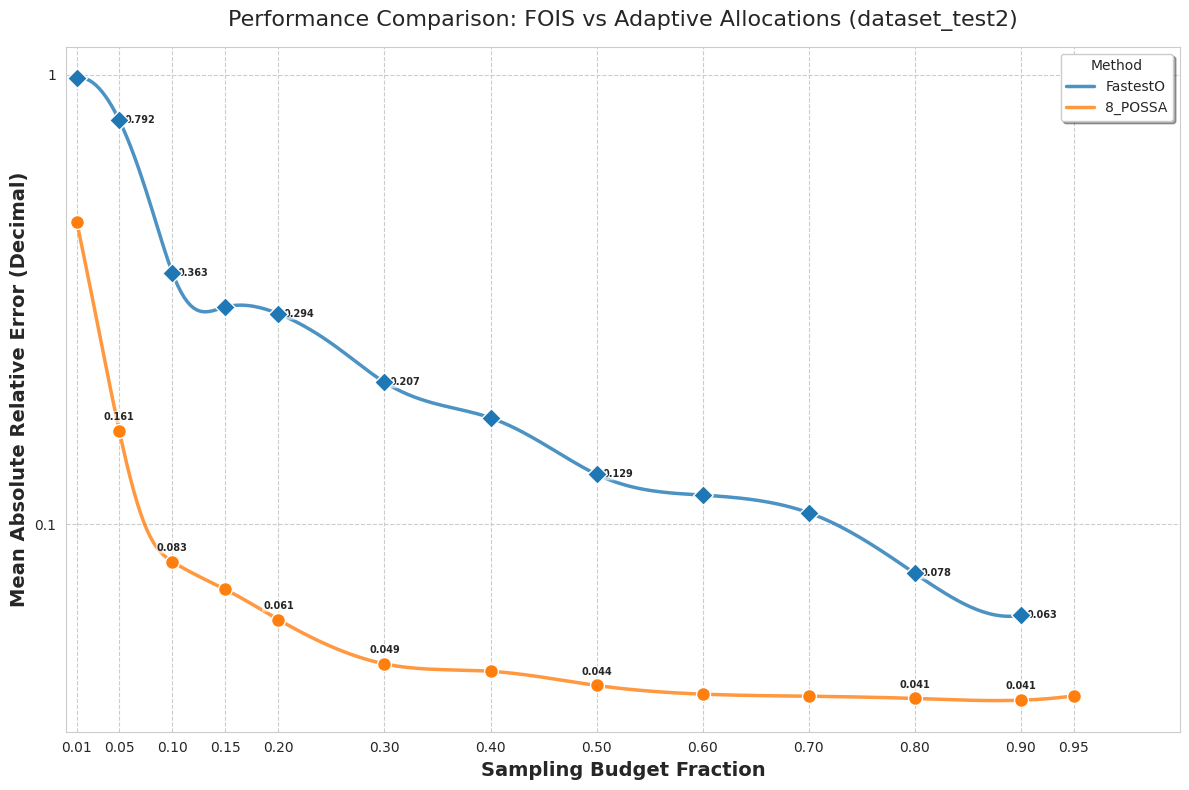


====== Summary of Mean ARE (Pivot) ======
method       5_ProxyE_Imp_Sqrt_WP  7_ProxyE_Imp_Sqrt_WP_NRS   8_POSSA  \
budget_frac                                                             
0.01                     0.496199                  0.494494  0.469339   
0.05                     0.217105                  0.171557  0.161168   
0.10                     0.124050                  0.088732  0.082552   
0.15                     0.072256                  0.067231  0.071556   
0.20                     0.058613                  0.060959  0.061298   
0.30                     0.050932                  0.054769  0.048873   
0.40                     0.046223                  0.052545  0.047046   
0.50                     0.043683                  0.052694  0.043752   
0.60                     0.042000                  0.051518  0.041845   
0.70                     0.041377                  0.051347  0.041397   
0.80                     0.040774                  0.051682  0.040931   
0.90    

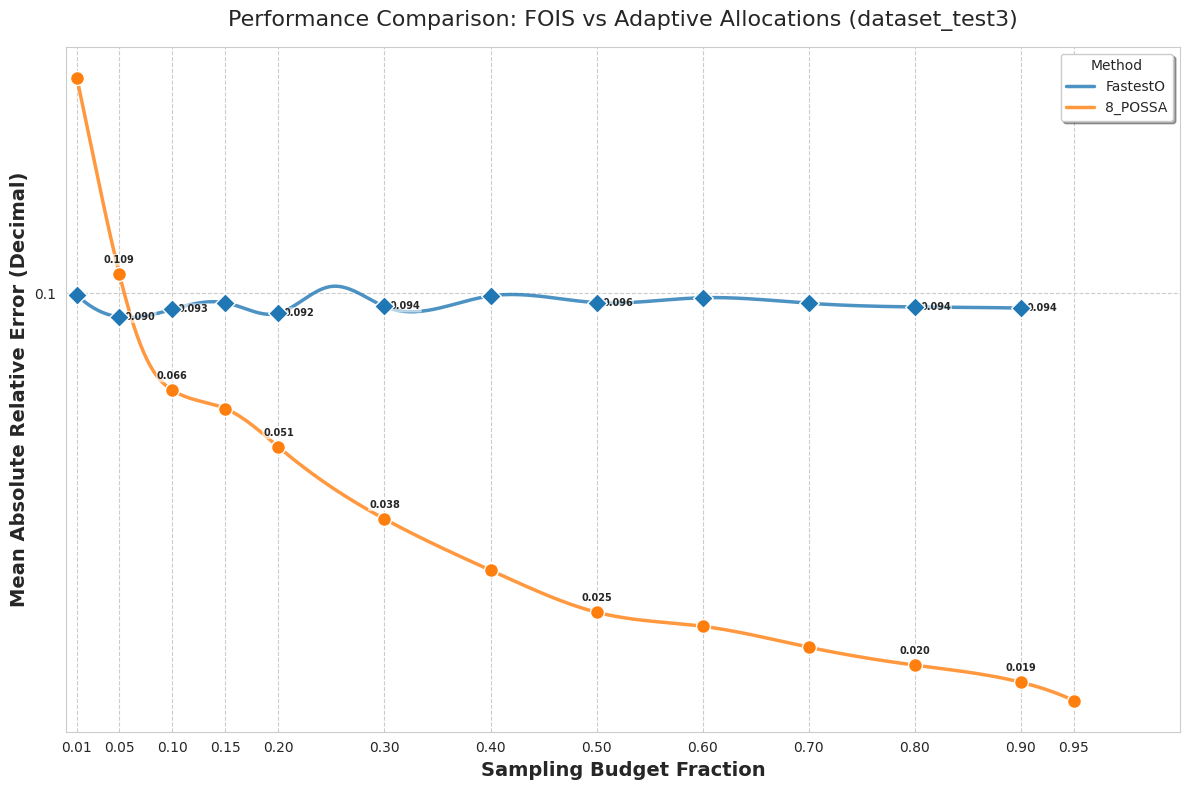


====== Summary of Mean ARE (Pivot) ======
method       5_ProxyE_Imp_Sqrt_WP  7_ProxyE_Imp_Sqrt_WP_NRS   8_POSSA  \
budget_frac                                                             
0.01                     0.244479                  0.239743  0.254152   
0.05                     0.111091                  0.098168  0.108717   
0.10                     0.072598                  0.072349  0.065668   
0.15                     0.060040                  0.051461  0.060626   
0.20                     0.052903                  0.041498  0.051339   
0.30                     0.038655                  0.033398  0.037575   
0.40                     0.028752                  0.029323  0.030087   
0.50                     0.029359                  0.026160  0.025081   
0.60                     0.022781                  0.024179  0.023596   
0.70                     0.021811                  0.022027  0.021548   
0.80                     0.019624                  0.020872  0.019942   
0.90    

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from matplotlib.ticker import FuncFormatter, ScalarFormatter
from scipy.interpolate import make_interp_spline

# ==========================================
# 0. 全局配置与样式定义
# ==========================================
# 【控制显示哪些方法】
# 如果你想隐藏某个方法，请在此列表中注释掉它
DESIRED_ORDER = [
    # "FOIS_nrs", 
    # "FOIS_rs", 
    "FastestO",             # <--- 保持原名 FastestO
    # "5_ProxyE_Imp_Sqrt_WP", 
    # "7_ProxyE_Imp_Sqrt_WP_NRS",
    "8_POSSA"
]

# 调色板
PALETTE = sns.color_palette("tab10", n_colors=len(DESIRED_ORDER))
COLOR_MAP = dict(zip(DESIRED_ORDER, PALETTE))

# 标记样式 (Keys 必须与 DESIRED_ORDER 中的名称一致)
MARKER_DICT = {
    "FOIS_nrs": "o", 
    "FOIS_rs": "s", 
    "FastestO": "D",        # <--- FastestO
    "5_ProxyE_Imp_Sqrt_WP": "v", 
    "7_ProxyE_Imp_Sqrt_WP_NRS": "h"
}

# 标签偏移
OFFSET_MAP = {
    "FOIS_nrs": (0, -15), 
    "FOIS_rs": (0, 15), 
    "FastestO": (15, 0),    # <--- FastestO
    "5_ProxyE_Imp_Sqrt_WP": (-10, 10), 
    "7_ProxyE_Imp_Sqrt_WP_NRS": (10, -15)
}

# ==========================================
# 1. 数据加载与处理函数
# ==========================================
def load_and_process_data(dataset_name, base_dir):
    """
    读取 CSV 文件，清洗数据，对齐 Ground Truth，计算 ARE 和 RE。
    返回: (df_all, wo_mean_error)
    """
    print(f"正在加载数据集: {dataset_name} ...")
    
    path_alloc_new = os.path.join(base_dir, "allocation_strategy_comparison.csv")
    path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
    path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
    path_wo_summary = os.path.join(base_dir, "WO_summary.csv") 

    dfs_to_merge = []

    # 1.1 读取 FOIS
    if not os.path.exists(path_fois):
        print(f"[Error] FOIS 文件不存在: {path_fois}")
        return None, None
    df_fois = pd.read_csv(path_fois)
    dfs_to_merge.append(df_fois)

    # 1.2 读取 FastestO
    if os.path.exists(path_fast):
        df_fast = pd.read_csv(path_fast)
        # 【修改】强制确保方法名为 FastestO (不改名为 WO)
        df_fast["method"] = "FastestO" 
        dfs_to_merge.append(df_fast)

    # 1.3 读取 Allocation Strategies
    if os.path.exists(path_alloc_new):
        df_alloc = pd.read_csv(path_alloc_new)
        dfs_to_merge.append(df_alloc)
    else:
        print(f"[Warn] 新策略文件未找到: {path_alloc_new}")

    # 1.4 读取 WO Summary (仅作为基准线数值)
    wo_mean_error = None
    if os.path.exists(path_wo_summary):
        try:
            df_sum = pd.read_csv(path_wo_summary)
            row = df_sum[df_sum["dataset_name"] == dataset_name]
            if not row.empty:
                wo_mean_error = row["mean_qerror"].iloc[0]
                print(f"✅ 已加载 WO 基准误差: {wo_mean_error}")
        except Exception as e:
            print(f"[Error] 读取 WO_summary.csv 失败: {e}")

    # 2. 数据清洗
    for df in dfs_to_merge:
        if "query_basename" in df.columns:
            df["query_basename"] = df["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    
    # 【已删除】这里不再包含将 FastestO 重命名为 WO 的代码

    # 3. 提取 GT 并对齐
    truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()

    df_final_list = []
    # 必要的列
    cols_needed = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

    for df in dfs_to_merge:
        temp_df = df.copy()
        # 如果不是源头文件，强制映射 GT
        if df is not df_fois:
            temp_df["T_true"] = temp_df["query_basename"].map(truth_map)
            temp_df = temp_df.dropna(subset=["T_true"])
        
        # 检查列是否存在
        if set(cols_needed).issubset(temp_df.columns):
            df_final_list.append(temp_df[cols_needed])

    df_all = pd.concat(df_final_list, ignore_index=True)

    # 4. 计算误差
    df_all = df_all[df_all["T_true"] != 0]
    # [绝对相对误差 ARE] -> 折线图
    df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()
    # [有符号相对误差 RE] -> 箱型图
    df_all["RE"] = (df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]

    return df_all, wo_mean_error

# ==========================================
# 2. 绘制误差收敛曲线函数
# ==========================================
def plot_error_convergence(df_all, wo_mean_error, dataset_name):
    """
    绘制随 Budget 变化的误差收敛曲线 (折线图)。
    """
    print("\n绘制误差收敛曲线...")
    
    # 聚合数据
    df_plot = df_all.groupby(["method", "budget_frac"])["ARE"].mean().reset_index()
    
    target_ticks = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
    
    sns.set_style("whitegrid", {"grid.linestyle": "--"})
    plt.figure(figsize=(12, 8))

    # 动态筛选：只绘制 DESIRED_ORDER 中存在且数据中也有的方法
    hue_order = [m for m in DESIRED_ORDER if m in df_plot["method"].unique()]

    for method in hue_order:
        subset = df_plot[df_plot["method"] == method].sort_values(by="budget_frac")
        x_raw = subset["budget_frac"].values
        y_raw = subset["ARE"].values

        # 平滑曲线
        if len(x_raw) > 3:
            try:
                x_new = np.linspace(x_raw.min(), x_raw.max(), 300)
                spl = make_interp_spline(x_raw, y_raw, k=3)
                y_smooth = spl(x_new)
                y_smooth = np.maximum(y_smooth, 0)
                plt.plot(x_new, y_smooth, color=COLOR_MAP.get(method, 'gray'), linewidth=2.5, alpha=0.8, label=method)
            except:
                plt.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'), linewidth=2.5, alpha=0.8, label=method)
        else:
            plt.plot(x_raw, y_raw, color=COLOR_MAP.get(method, 'gray'), linewidth=2.5, alpha=0.8, label=method)

        # 绘制散点
        mask = [any(np.isclose(x, t, atol=1e-3) for t in target_ticks) for x in x_raw]
        x_pts = x_raw[mask]
        y_pts = y_raw[mask]
        
        if len(x_pts) > 0:
            mk = MARKER_DICT.get(method, "o")
            plt.scatter(x_pts, y_pts, color=COLOR_MAP.get(method, 'gray'), marker=mk, s=100, zorder=5, edgecolor='white', linewidth=1)
            
            # 添加数值标签
            for i in range(len(x_pts)):
                # 仅在部分点显示标签，避免拥挤
                if x_pts[i] in [0.05, 0.1, 0.2,0.3, 0.5, 0.8,0.9, 1.0]: 
                    lbl = f"{y_pts[i]:.3f}"
                    off = OFFSET_MAP.get(method, (0, 10))
                    plt.annotate(lbl, xy=(x_pts[i], y_pts[i]), xytext=off, textcoords="offset points", 
                                 ha="center", va="center", fontsize=7, fontweight="bold", 
                                 bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.6, ec="none"))

    # 绘制 WO 基准线 (来自 WO_summary.csv)
    if wo_mean_error is not None:
        plt.axhline(y=wo_mean_error, color='black', linestyle='--', linewidth=1.5, alpha=0.7, zorder=1)
        plt.text(1.02, wo_mean_error, f"WO Mean:\n{wo_mean_error:.4f}", 
                 color='black', fontsize=9, fontweight='bold', va='center', ha='left', 
                 transform=plt.gca().get_yaxis_transform())

    # 坐标轴设置
    ax = plt.gca()
    plt.xscale("linear")
    plt.xlabel("Sampling Budget Fraction", fontsize=14, fontweight="bold")
    plt.xlim(0, 1.05)
    ax.set_xticks(target_ticks)
    ax.get_xaxis().set_major_formatter(ScalarFormatter())

    plt.yscale("log")
    plt.ylabel("Mean Absolute Relative Error (Decimal)", fontsize=14, fontweight="bold")
    
    def decimal_formatter(x, pos): return f"{x:.2g}"
    ax.yaxis.set_major_formatter(FuncFormatter(decimal_formatter))

    plt.title(f"Performance Comparison: FOIS vs Adaptive Allocations ({dataset_name})", fontsize=16, pad=15)
    plt.legend(title="Method", fontsize=10, loc="best", frameon=True, shadow=True)
    plt.tight_layout()
    plt.show()
    
    # 打印 Summary Pivot
    print("\n====== Summary of Mean ARE (Pivot) ======")
    df_filtered = df_plot[df_plot["budget_frac"].apply(lambda x: any(np.isclose(x, t, atol=1e-3) for t in target_ticks))]
    print(df_filtered.pivot(index="budget_frac", columns="method", values="ARE"))


# ==========================================
# 3. 绘制箱型图函数 (带散点 & 自定义范围)
# ==========================================
def plot_boxplot_at_budget(df_all, wo_mean_error, dataset_name, target_budget=0.1, y_range=None, show_scatter=True):
    """
    绘制指定采样率下的误差分布箱型图 (带红蓝散点)。
    """
    print(f"\n正在绘制采样率 {target_budget} 的箱型图 (带散点)...")

    # 1. 筛选数据
    mask_budget = df_all["budget_frac"].apply(lambda x: np.isclose(x, target_budget, atol=1e-3))
    df_box_target = df_all[mask_budget].copy()

    if df_box_target.empty:
        print(f"[Warn] 没有找到 Budget = {target_budget} 的数据。")
        return

    # 筛选方法
    hue_order = [m for m in DESIRED_ORDER if m in df_box_target["method"].unique()]
    df_box_target = df_box_target[df_box_target["method"].isin(hue_order)]
    
    # 2. 标记误差方向 (用于散点颜色)
    df_box_target['Error_Dir'] = df_box_target['RE'].apply(
        lambda x: 'Over (>0)' if x > 0 else ('Under (<0)' if x < 0 else 'Exact')
    )
    
    plt.figure(figsize=(12, 8))
    
    # 3. 绘制箱型图 (Box Plot)
    sns.boxplot(
        data=df_box_target,
        x="method",
        y="RE",
        order=hue_order,
        palette=COLOR_MAP,
        showfliers=False,  # 隐藏异常值，由散点展示
        linewidth=1.5,
        boxprops=dict(alpha=0.2) # 淡化箱体
    )
    
    # 4. 绘制散点图 (Strip Plot)
    if show_scatter:
        scatter_palette = {'Over (>0)': 'red', 'Under (<0)': 'blue', 'Exact': 'green'}
        
        sns.stripplot(
            data=df_box_target,
            x="method",
            y="RE",
            hue="Error_Dir",
            order=hue_order,
            palette=scatter_palette,
            dodge=False, 
            jitter=True, 
            alpha=0.6,
            s=4
        )
    
    # 5. 绘制参考线
    # 0 误差线 (完美)
    plt.axhline(y=0, color='green', linestyle='-', linewidth=2.0, alpha=0.8, zorder=0)
    plt.text(-0.45, 0, "Zero Error (Perfect)", color='green', fontsize=10, fontweight='bold', va='bottom')

    # WO Mean Line (绘制两条虚线表示 +/- Mean Error 范围)
    if wo_mean_error is not None:
        plt.axhline(y=wo_mean_error, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
        plt.axhline(y=-wo_mean_error, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
        plt.text(len(hue_order)-0.5, wo_mean_error, f"+WO MAE: {wo_mean_error:.3f}", color='gray', fontsize=8)

    # 6. 设置坐标轴与范围
    plt.ylabel("Signed Relative Error (RE)", fontsize=12, fontweight="bold")
    plt.xlabel("Method", fontsize=12, fontweight="bold")
    plt.title(f"Signed Error Distribution at Budget = {target_budget} ({dataset_name})", fontsize=14, pad=15)
    
    # --- 用户自定义 Y 轴范围 ---
    if y_range is not None:
        plt.ylim(y_range)
        print(f"已应用自定义 Y 轴范围: {y_range}")

    # 处理图例
    ax = plt.gca()
    if show_scatter:
        handles, labels = ax.get_legend_handles_labels()
        wanted_labels = ['Over (>0)', 'Under (<0)']
        filtered_handles = []
        filtered_labels = []
        seen = set()
        for h, l in zip(handles, labels):
            if l in wanted_labels and l not in seen:
                filtered_handles.append(h)
                filtered_labels.append(l)
                seen.add(l)
        
        if filtered_handles:
            plt.legend(filtered_handles, filtered_labels, title="Error Direction", loc="upper right")
    else:
        # 如果不显示散点，移除图例
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    plt.grid(True, axis='y', linestyle="--", linewidth=0.5, alpha=0.7)
    plt.xticks(rotation=15)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计
    print(f"\n====== Statistics at Budget {target_budget} (Signed RE) ======")
    stats = df_box_target.groupby("method")["RE"].describe()[['count', 'mean', 'std', 'min', '50%', 'max']]
    print(stats)


# ==========================================
# 4. 主执行块
# ==========================================
# ==========================================
# 4. 主执行块 (批量处理)
# ==========================================
if __name__ == "__main__":
    
    # 在这里定义所有需要处理的数据集名称列表
    # 脚本会依次遍历列表中的每个名字
    DATASET_LIST = [
        'dataset_three', 
        'dataset_test', 
        'dataset_test2', 
        'dataset_test3'
    ]

    for current_dataset in DATASET_LIST:
        print(f"\n{'='*50}")
        print(f"🚀 开始处理数据集: {current_dataset}")
        print(f"{'='*50}")

        # 动态构建路径
        BASE_DIR = f"/home/wangshuo/resource/datasets/parler_data/{current_dataset}/results/efficiency"
        
        # 简单检查目录是否存在，避免报错中断循环
        if not os.path.exists(BASE_DIR):
            print(f"[Skip] 目录不存在，跳过: {BASE_DIR}")
            continue

        # 1. 加载数据
        df_data, wo_error = load_and_process_data(current_dataset, BASE_DIR)
        
        if df_data is not None:
            try:
                # 2. 绘制折线图
                plot_error_convergence(df_data, wo_error, current_dataset)
                
                # 3. 绘制箱型图 (示例：Budget=0.1, 限制 Y 轴范围)
                plot_boxplot_at_budget(
                    df_data, 
                    wo_error, 
                    current_dataset, 
                    target_budget=0., 
                    y_range=(-0.5, 0.5),  # <--- 用户自定义范围
                    show_scatter=False     # <--- 用户控制是否显示散点
                )
                
                # 你可以在这里添加更多采样率的箱型图绘制，例如:
                # plot_boxplot_at_budget(df_data, wo_error, current_dataset, target_budget=0.3, show_scatter=False)

            except Exception as e:
                print(f"[Error] 绘图过程中发生错误 ({current_dataset}): {e}")
        else:
            print(f"[Info] 数据集 {current_dataset} 加载数据为空或文件缺失。")

        print(f"\n✅ 数据集 {current_dataset} 处理完毕。\n")

#### 5.

##### 5.1添加proxyE
读取上面相应文件,在指定采样率下,对于每个方法(FOIS_nrs \ FOIS_rs \ FastestO \ 四种分层采样)绘制绝对平均误差的CDF图

正在读取并对齐数据...


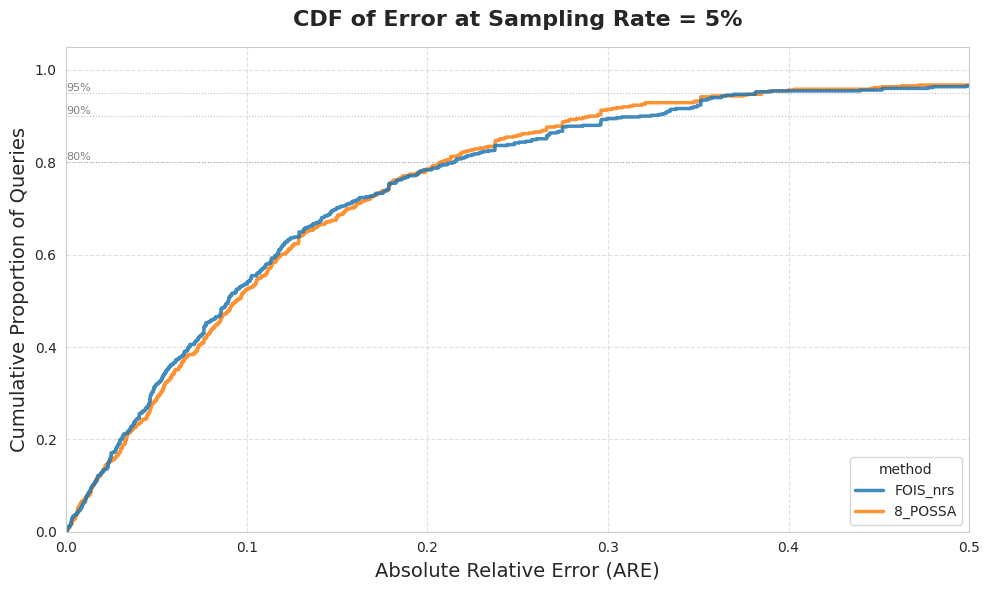


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.05]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1489     | 0.0898     | 0.0898     | 0.1786     | 0.3182     | 0.3815     | 1.7101    
8_POSSA                   | 0.1475     | 0.0943     | 0.0943     | 0.1790     | 0.2900     | 0.3851     | 1.7101    



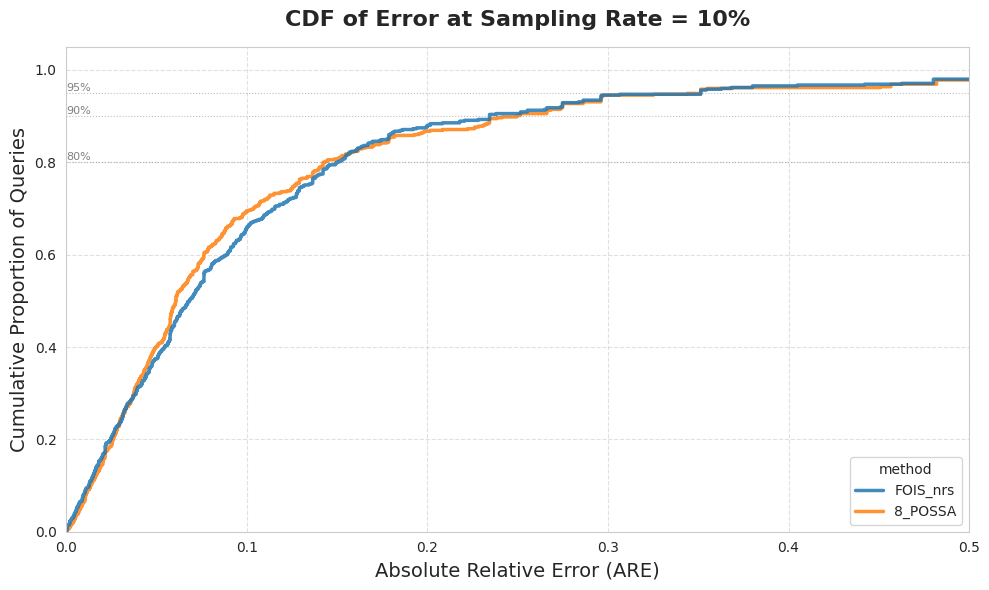


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.1]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1172     | 0.0682     | 0.0682     | 0.1317     | 0.2344     | 0.3514     | 1.7101    
8_POSSA                   | 0.1157     | 0.0606     | 0.0606     | 0.1264     | 0.2494     | 0.3480     | 1.7101    



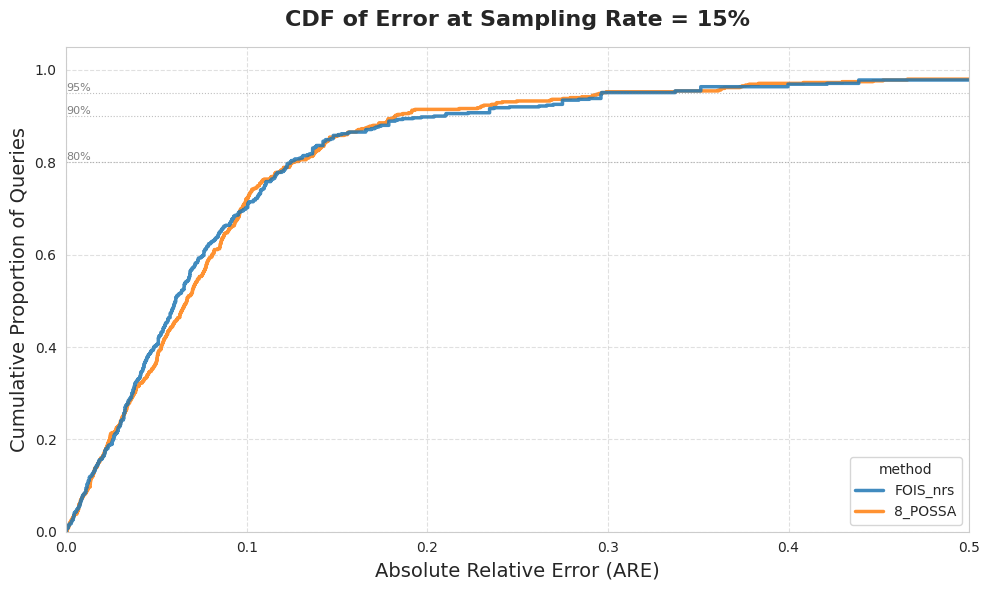


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.15]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1092     | 0.0606     | 0.0606     | 0.1100     | 0.2043     | 0.2965     | 1.7101    
8_POSSA                   | 0.1200     | 0.0667     | 0.0667     | 0.1066     | 0.1820     | 0.2959     | 7.3448    



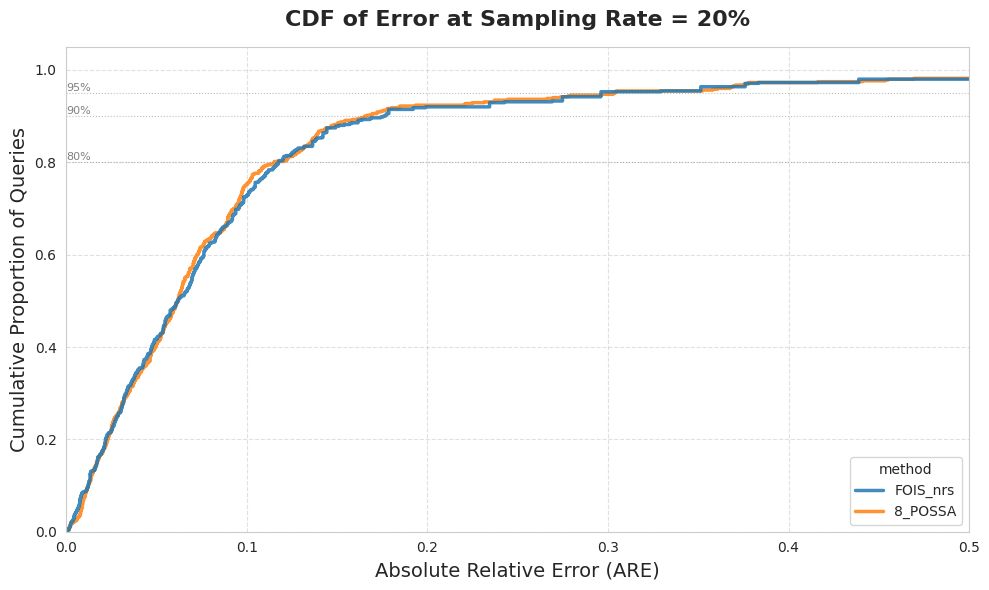


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.2]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1043     | 0.0619     | 0.0619     | 0.1046     | 0.1756     | 0.2961     | 1.7101    
8_POSSA                   | 0.1017     | 0.0617     | 0.0617     | 0.0991     | 0.1655     | 0.3032     | 1.7609    



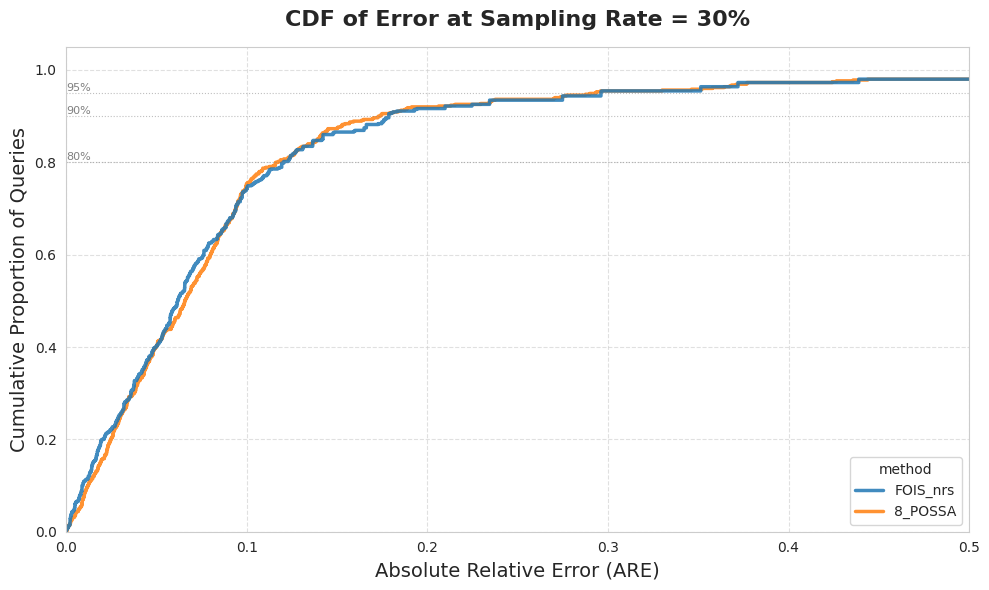


  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget=0.3]
Method                    | Mean       | Median     | P50        | P75        | P90        | P95        | Max       
---------------------------------------------------------------------------------------------------------
FOIS_nrs                  | 0.1040     | 0.0617     | 0.0617     | 0.1019     | 0.1786     | 0.2961     | 1.7101    
8_POSSA                   | 0.1047     | 0.0657     | 0.0657     | 0.0997     | 0.1730     | 0.2918     | 1.7435    



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==========================================
# 1. 配置参数
# ==========================================
dataset_name = 'dataset_test'
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}/results/efficiency"

# 文件路径
# path_fois = os.path.join(base_dir, "FOIS_rs_POSS_budget_curve.csv")
path_fois = os.path.join(base_dir, "FOIS_rs_FOSS_nrs_budget_curve_fast.csv")
path_fast = os.path.join(base_dir, "FastestO_budget_curve.csv")
path_alloc = os.path.join(base_dir, "allocation_strategy_comparison.csv")

# --- 指定要绘制 CDF 的采样率 (Budget Fraction) ---
PLOTTING_BUDGETS = [0.05, 0.1,0.15,0.2, 0.3] 

# x轴截断
X_LIMIT = 0.5

# ==========================================
# 2. 数据加载与对齐
# ==========================================
print("正在读取并对齐数据...")

dfs = []

# 2.1 加载 FOIS (基准)
if os.path.exists(path_fois):
    df_fois = pd.read_csv(path_fois)
    dfs.append(df_fois)
    df_fois["query_basename"] = df_fois["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    truth_map = df_fois[["query_basename", "T_true"]].drop_duplicates(subset=["query_basename"]).set_index("query_basename")["T_true"].to_dict()
else:
    print(f"[Error] 基准文件缺失: {path_fois}")
    exit()

# 2.2 加载 FastestO
if os.path.exists(path_fast):
    df_fast = pd.read_csv(path_fast)
    df_fast["method"] = "FastestO"
    dfs.append(df_fast)

# 2.3 加载 分层策略对比
if os.path.exists(path_alloc):
    df_alloc = pd.read_csv(path_alloc)
    dfs.append(df_alloc)

# 2.4 合并与计算 ARE
df_final_list = []
target_cols = ["query_basename", "method", "budget_frac", "T_hat", "T_true"]

for df in dfs:
    temp = df.copy()
    if "query_basename" in temp.columns:
        temp["query_basename"] = temp["query_basename"].astype(str).str.replace(r"\.graph$", "", regex=True)
    
    if df is not df_fois:
        temp["T_true"] = temp["query_basename"].map(truth_map)
        temp = temp.dropna(subset=["T_true"])

    if set(target_cols).issubset(temp.columns):
        df_final_list.append(temp[target_cols])

df_all = pd.concat(df_final_list, ignore_index=True)

# 计算绝对相对误差 (ARE)
df_all = df_all[df_all["T_true"] != 0]
df_all["ARE"] = ((df_all["T_hat"] - df_all["T_true"]) / df_all["T_true"]).abs()

# ==========================================
# 3. 绘图配置
# ==========================================
desired_order = [
    "FOIS_nrs",
    # "FOIS_rs", "FastestO",
    # "1_Proxy_Imp_Pilot", "2_ProxyE_Imp_Pilot", 
    # "3_ProxyE_Imp_RootWP", "4_ProxyE_Imp_WRootMeanP",    "5_ProxyE_Imp_Sqrt_WP",
    # "6_ProxyE_Imp_Neyman",'7_ProxyE_Imp_Sqrt_WP_NRS',
    '8_POSSA'
]
available_methods = [m for m in desired_order if m in df_all["method"].unique()]

palette = sns.color_palette("tab10", n_colors=len(available_methods))
color_map = dict(zip(available_methods, palette))

# ==========================================
# 4. 循环绘制 CDF 及 打印详细统计
# ==========================================
sns.set_style("whitegrid")

for budget in PLOTTING_BUDGETS:
    # 筛选数据
    mask = df_all["budget_frac"].apply(lambda x: np.isclose(x, budget, atol=1e-4))
    subset = df_all[mask].copy()
    
    if subset.empty:
        print(f"[Warn] Budget = {budget} 没有找到任何数据行，跳过绘图。")
        continue

    subset = subset.dropna(subset=["ARE"])
    if subset.empty:
        print(f"[Warn] Budget = {budget} 的 ARE 全为 NaN，跳过绘图。")
        continue

    current_methods = [m for m in desired_order if m in subset["method"].unique()]
    
    if not current_methods:
        continue

    # --- 绘图 ---
    plt.figure(figsize=(10, 6))
    
    ax = sns.ecdfplot(
        data=subset, 
        x="ARE", 
        hue="method", 
        hue_order=current_methods,
        palette=color_map,
        linewidth=2.5,
        alpha=0.85
    )

    plt.title(f"CDF of Error at Sampling Rate = {int(budget*100)}%", fontsize=16, fontweight="bold", pad=15)
    plt.xlabel("Absolute Relative Error (ARE)", fontsize=14)
    plt.ylabel("Cumulative Proportion of Queries", fontsize=14)
    
    if X_LIMIT:
        plt.xlim(0, X_LIMIT)
    plt.ylim(0, 1.05)
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        plt.legend(handles=handles, labels=labels, title="Method", fontsize=10, loc="lower right", frameon=True, shadow=True)

    plt.grid(True, linestyle="--", alpha=0.6)
    for y_line in [0.8, 0.9, 0.95]:
        plt.axhline(y=y_line, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
        plt.text(0, y_line, f"{int(y_line*100)}%", color='gray', fontsize=8, va="bottom")

    plt.tight_layout()
    plt.show()
    
    # =========================================================
    # --- [关键修改] 打印详细统计表格 ---
    # =========================================================
    stats_data = []
    for m in current_methods:
        m_data = subset[subset["method"] == m]["ARE"]
        if not m_data.empty:
            stats_data.append({
                "Method": m,
                "Mean": m_data.mean(),
                "Median": m_data.median(),
                "P50": m_data.median(), # Median 和 P50 是同一个值，这里按要求列出
                "P75": m_data.quantile(0.75),
                "P90": m_data.quantile(0.90),
                "P95": m_data.quantile(0.95),
                "Max": m_data.max()
            })
            
    # 如果有统计数据，进行格式化输出
    if stats_data:
        print(f"\n  AQP Evaluation Metrics Summary (Dynamic Percentiles) [Budget={budget}]")
        print("=" * 105)
        # 表头
        print(f"{'Method':<25} | {'Mean':<10} | {'Median':<10} | {'P50':<10} | {'P75':<10} | {'P90':<10} | {'P95':<10} | {'Max':<10}")
        print("-" * 105)
        
        # 数据行
        for row in stats_data:
            print(f"{row['Method']:<25} | "
                  f"{row['Mean']:<10.4f} | "
                  f"{row['Median']:<10.4f} | "
                  f"{row['P50']:<10.4f} | "
                  f"{row['P75']:<10.4f} | "
                  f"{row['P90']:<10.4f} | "
                  f"{row['P95']:<10.4f} | "
                  f"{row['Max']:<10.4f}")
        print("=" * 105 + "\n")